In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vulligadlayasmeen/coaster/coaster_db.csv


Step 0 - Imports and Reading ddata

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [3]:
df= pd.read_csv('/kaggle/input/datasets/vulligadlayasmeen/coaster/coaster_db.csv')

Step 1: Data Understanding
- Dataframe shape
- Head and tail
- dtypes
- describe

In [4]:
df.shape

(1087, 56)

In [5]:
df.head(5)

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,Height,Inversions,Lift/launch system,Cost,Trains,Park section,Duration,Capacity,G-force,Designer,Max vertical angle,Drop,Soft opening date,Fast Lane available,Replaced,Track layout,Fastrack available,Soft opening date.1,Closing date,Opened,Replaced by,Website,Flash Pass Available,Must transfer from wheelchair,Theme,Single rider line available,Restraint Style,Flash Pass available,Acceleration,Restraints,Name,year_introduced,latitude,longitude,Type_Main,opening_date_clean,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,50 ft (15 m),NaN,gravity,NaN,NaN,Coney Island Cyclone Site,1:00,1600 riders per hour,2.9,LaMarcus Adna Thompson,30°,43 ft (13 m),NaN,NaN,NaN,Gravity pulled coaster,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1884,40.5740,-73.9780,Wood,1884-06-16,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 1 across in ...,NaN,NaN,NaN,12,Lina Beecher,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1896,41.5800,-81.5700,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 2 across in ...,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,Switchback Railway,NaN,NaN,NaN,1910,NaN,Giant Racer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


Step 2: Data Preparation
* Dropping irrelavant columns and rows
* Identifying duplicated columns
* Renaming Columns
* Feature Creation

In [6]:
 print(df.columns.tolist())

['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date', 'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height', 'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section', 'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle', 'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced', 'Track layout', 'Fastrack available', 'Soft opening date.1', 'Closing date', 'Opened', 'Replaced by', 'Website', 'Flash Pass Available', 'Must transfer from wheelchair', 'Theme', 'Single rider line available', 'Restraint Style', 'Flash Pass available', 'Acceleration', 'Restraints', 'Name', 'year_introduced', 'latitude', 'longitude', 'Type_Main', 'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit', 'speed_mph', 'height_value', 'height_unit', 'height_ft', 'Inversions_clean', 'Gforce_clean']


In [7]:
df=df[['coaster_name', 
     #'Length', 'Speed', 'Location', 'Status', 'Opening date','Type',
      'Manufacturer',
     #'Height restriction', 'Model', 'Height',
      # 'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       #'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       #'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced','Track layout', 'Fastrack available', 'Soft opening date.1','Closing date', 
     #'Opened', 'Replaced by', 'Website', 'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       #'Single rider line available', 'Restraint Style',
       #'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 
     #'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph',
     #'height_value', 'height_unit',
     'height_ft','Inversions_clean','Gforce_clean']].copy()

In [8]:
df['opening_date_clean'] = pd.to_datetime(df['opening_date_clean'])

In [9]:
#rename our columns
df=df.rename(columns={'coaster_name':'Coaster_Name',
                    'year_introduced':'Year_Introduced',
                    'opening_date_clean':'Opening_Date_Clean',
                    'height_ft':'Height_Ft',
                    'Inversions_clean':'Inversions_Clean',
                    'Gforce_clean':'Gforce_Clean'  })

In [10]:
df.head()

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
0,Switchback Railway,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [11]:
df.isna().sum() #nullvaluecheck

Coaster_Name            0
Manufacturer           59
Year_Introduced         0
latitude              275
longitude             275
Type_Main               0
Opening_Date_Clean    250
speed_mph             150
Height_Ft             916
Inversions_Clean        0
Gforce_Clean          725
dtype: int64

In [12]:
df.loc[df.duplicated()]

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean


In [13]:
df.loc[df.duplicated(subset=['Coaster_Name'])]

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
43,Crystal Beach Cyclone,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
60,Derby Racer,Fred W. Pearce,1937,42.4200,-70.9860,Wood,1911-01-01,NaN,NaN,0,NaN
61,Blue Streak (Conneaut Lake),NaN,1938,41.6349,-80.3180,Wood,1938-05-23,50.0,NaN,0,NaN
167,Big Thunder Mountain Railroad,Arrow Development (California and Florida)Dyna...,1980,NaN,NaN,Steel,NaT,35.0,NaN,0,NaN
237,Thunder Run (Canada's Wonderland),Mack Rides,1986,43.8427,-79.5423,Steel,1981-05-23,39.8,32.8,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1063,Lil' Devil Coaster,Zamperla,2021,40.1343,-74.4434,Steel,1999-01-01,NaN,NaN,0,NaN
1064,Little Dipper (Conneaut Lake Park),Allan Herschell Company,2021,41.6343,-80.3165,Steel,1950-01-01,NaN,NaN,0,NaN
1080,Iron Gwazi,Rocky Mountain Construction,2022,28.0339,-82.4231,Steel,NaT,76.0,NaN,2,NaN
1082,American Dreier Looping,Anton Schwarzkopf,2022,NaN,NaN,Steel,NaT,53.0,NaN,3,4.7


In [14]:
#Checking an example duplicates
df.query('Coaster_Name=="Crystal Beach Cyclone"')

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
39,Crystal Beach Cyclone,Traver Engineering,1926,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
43,Crystal Beach Cyclone,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0


In [15]:
df.columns

Index(['Coaster_Name', 'Manufacturer', 'Year_Introduced', 'latitude',
       'longitude', 'Type_Main', 'Opening_Date_Clean', 'speed_mph',
       'Height_Ft', 'Inversions_Clean', 'Gforce_Clean'],
      dtype='object')

In [16]:
df=df.loc[~df.duplicated(subset=['Coaster_Name','Opening_Date_Clean'])] \
.reset_index(drop=True)

In [17]:
df.shape

(990, 11)

Step 3: Feature Understanding
(Univarate analysis)
* Plotting Feature Distributions
* Histogram
* KDE
* Boxplot

In [18]:
df['Year_Introduced'].value_counts()

Year_Introduced
1999    46
2000    45
1998    30
2001    29
2002    28
        ..
1952     1
1956     1
1961     1
1955     1
1959     1
Name: count, Length: 101, dtype: int64

Text(0, 0.5, 'Count')

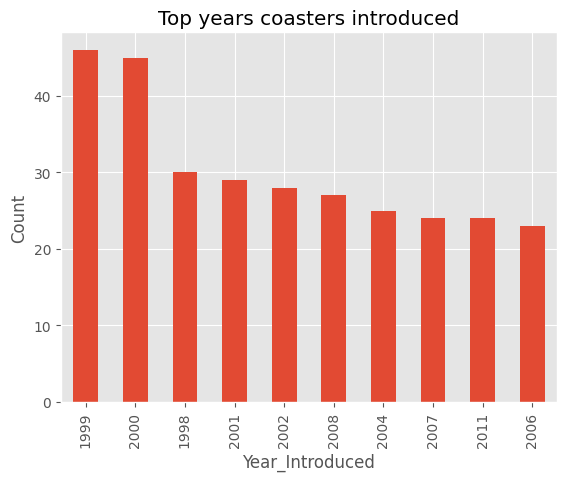

In [19]:
ax=df['Year_Introduced'].value_counts() \
.head(10) \
.plot(kind='bar',title='Top years coasters introduced')
ax.set_xlabel('Year_Introduced')
ax.set_ylabel('Count')

Step 4: Feature Relationships
* Scatterplot
* Heatmap Correlation
* Pairplot
* Groupby comparisions

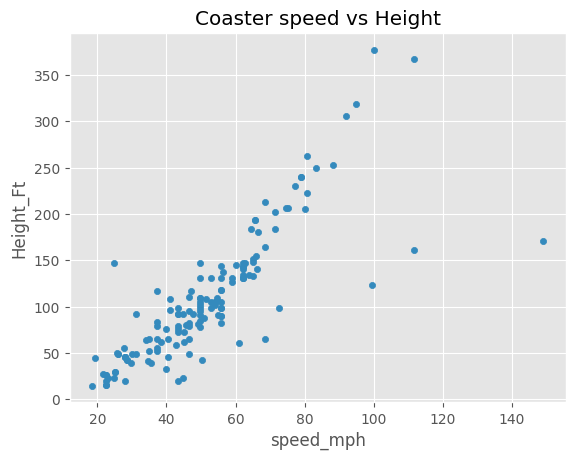

In [20]:
df.plot(kind="scatter",
       x="speed_mph",
       y="Height_Ft",
       title='Coaster speed vs Height')
plt.show()

Text(0.5, 1.0, 'Coaster Speed vs Height')

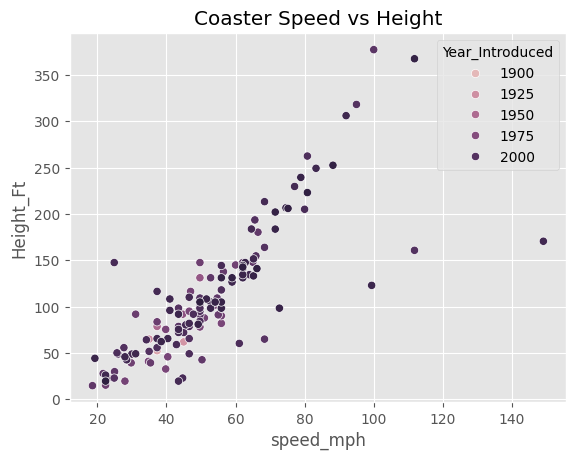

In [21]:
ax=sns.scatterplot(x='speed_mph',
               y='Height_Ft',
               hue="Year_Introduced",
               data=df)
ax.set_title('Coaster Speed vs Height')

In [22]:
df.head()

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
0,Switchback Railway,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


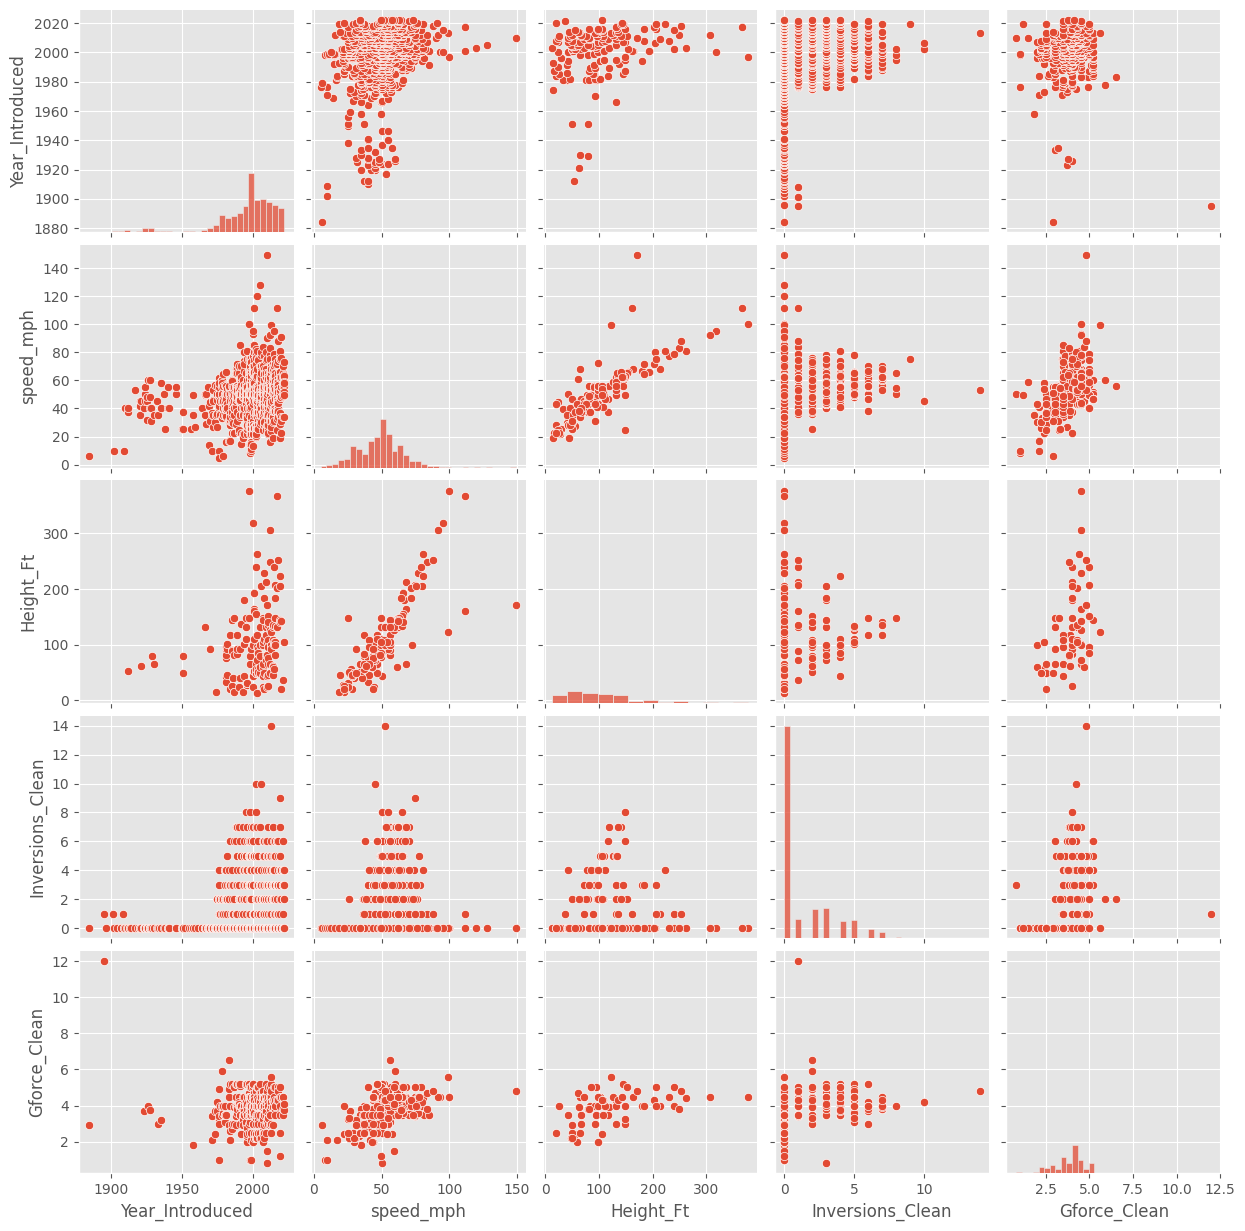

In [23]:
sns.pairplot(df,vars=['Year_Introduced','speed_mph','Height_Ft','Inversions_Clean','Gforce_Clean'])
plt.show()

In [24]:
df_corr=df[['Year_Introduced','speed_mph','Height_Ft','Inversions_Clean','Gforce_Clean']].dropna().corr()
df_corr

,Year_Introduced,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
Year_Introduced,1.000000,0.171978,0.135413,-0.209887,0.160247
speed_mph,0.171978,1.000000,0.733999,-0.028705,0.607383
Height_Ft,0.135413,0.733999,1.000000,-0.079736,0.466482
Inversions_Clean,-0.209887,-0.028705,-0.079736,1.000000,0.275991
Gforce_Clean,0.160247,0.607383,0.466482,0.275991,1.000000


<Axes: >

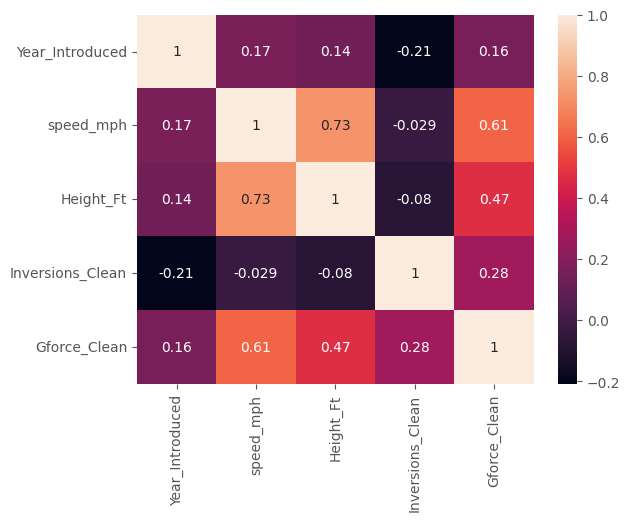

In [25]:
sns.heatmap(df_corr,annot=True)

Step 5: Asking a question about the data
* What are the latitude with the fastest roller coasters ?
  

In [26]:
df.head()

,Coaster_Name,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date_Clean,speed_mph,Height_Ft,Inversions_Clean,Gforce_Clean
0,Switchback Railway,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [27]:
# 1. Check the data after grouping and counting
check_df = df.query('latitude != "Other"') \
    .groupby('latitude')['speed_mph'] \
    .agg(['mean', 'count'])

print("Data before filtering for count >= 10:")
print(check_df)

# 2. Check the data AFTER the count filter
final_check = check_df.query('count >= 10')
print("\nData after filtering for count >= 10:")
print(final_check)

Data before filtering for count >= 10:
          mean  count
latitude             
-48.2617  49.0      1
-33.8012   NaN      0
-33.8008  55.9      1
-32.0970   NaN      0
-32.0955  52.8      1
...        ...    ...
 60.1886  37.3      1
 63.2298  47.0      1
 63.2306  48.0      1
 63.2307  62.1      1
 63.2309  64.9      1

[688 rows x 2 columns]

Data after filtering for count >= 10:
Empty DataFrame
Columns: [mean, count]
Index: []


Text(0, 0.5, 'Avg Speed (mph)')

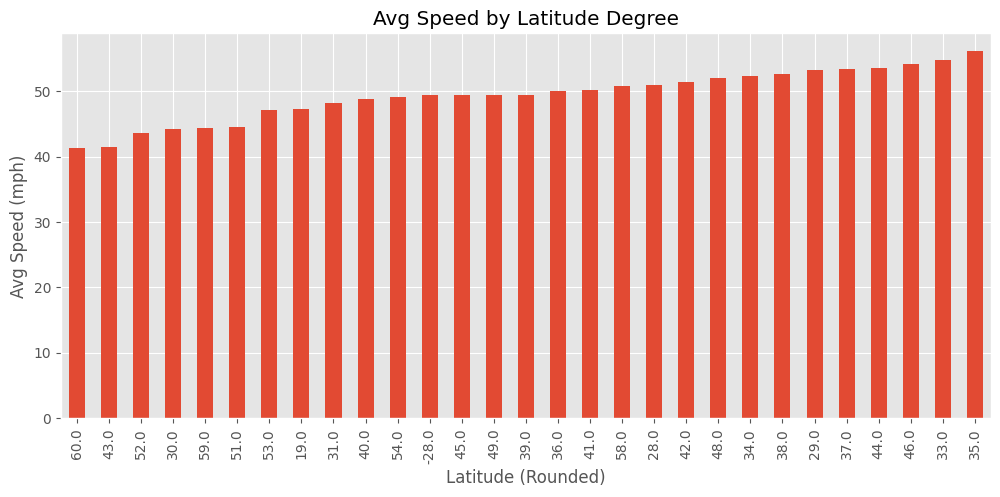

In [28]:
# 1. Round the latitude so coasters in the same area group together
df['lat_bin'] = df['latitude'].astype(float).round(0) 

# 2. Run your analysis on the 'lat_bin' instead of raw 'latitude'
ax = df.query('latitude != "Other"') \
    .groupby('lat_bin')['speed_mph'] \
    .agg(['mean', 'count']) \
    .query('count >= 5') \
    .sort_values('mean')['mean'] \
    .plot(kind='bar', figsize=(12, 5), title='Avg Speed by Latitude Degree')

ax.set_xlabel('Latitude (Rounded)')
ax.set_ylabel('Avg Speed (mph)')